In [1]:
import os, sys
import subprocess
import json
import uproot3
import awkward as ak
import numpy as np
from coffea import processor, util, hist
import pickle
import matplotlib.pyplot as plt

/opt/conda/lib/python3.8/site-packages/coffea/util.py:154: FutureWarning: In coffea version v0.8.0 (target date: 31 Dec 2022), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [2]:
year = '2018'
ddbthr = 0.72
ddcthr = 0.15

In [3]:
with open('xsec.json') as f:
    xs = json.load(f)
        
with open('pmap.json') as f:
    pmap = json.load(f)

with open('lumi.json') as f:
    lumis = json.load(f)

In [6]:
!ls ../outfiles_allyearsRun_Oct192022_2018

2018_dask_Diboson.coffea       2018_dask_TTbarBoosted.coffea
2018_dask_DibosonNLO.coffea    2018_dask_VBFHToBB.coffea
2018_dask_EWKV.coffea	       2018_dask_WHToBB.coffea
2018_dask_GluGluHToBB.coffea   2018_dask_WJetsToLNu.coffea
2018_dask_JetHTData.coffea     2018_dask_WJetsToQQ.coffea
2018_dask_QCD.coffea	       2018_dask_ZHToBB.coffea
2018_dask_SingleMuData.coffea  2018_dask_ZJetsToQQ.coffea
2018_dask_SingleTop.coffea     2018_dask_ttHToBB.coffea
2018_dask_TTbar.coffea


In [7]:
indir = "../outfiles_allyearsRun_Oct192022_2018/"
infiles = subprocess.getoutput("ls "+indir+year+"_dask_QCD.coffea").split()
outsum = processor.dict_accumulator()

In [8]:
started = 0
for filename in infiles:

    print("Loading "+filename)

    if os.path.isfile(filename):
        out = util.load(filename)

        if started == 0:
            outsum['templates'] = out['templates']
            outsum['sumw'] = out['sumw']
            started += 1
        else:
            outsum['templates'].add(out['templates'])
            outsum['sumw'].add(out['sumw'])

        del out

scale_lumi = {k: xs[k] * 1000 * lumis[year] / w for k, w in outsum['sumw'].items()} 

outsum['templates'].scale(scale_lumi, 'dataset')
templates = outsum['templates'].integrate('systematic','nominal')

Loading ../outfiles_allyearsRun_Oct192022_2018/2018_dask_QCD.coffea


In [9]:
colors = ['violet','red','orange','gold','lime','green','deepskyblue','blue','black','gray']
datasets = ['QCD_Pt_170to300','QCD_Pt_300to470','QCD_Pt_470to600','QCD_Pt_600to800','QCD_Pt_800to1000','QCD_Pt_1000to1400','QCD_Pt_1400to1800','QCD_Pt_1800to2400','QCD_Pt_2400to3200','QCD_Pt_3200toInf']

In [10]:
pass_light = []
pass_charm = []
fail_light = []
fail_charm = []

histnames = ['Pass, Light','Pass, Charm','Fail, Light','Fail, Charm']

sig = templates.integrate('region','signal').sum(*['genflavor1', 'genflavor2', 'msd2'], overflow='all')

pass_light += [sig.integrate('ddb1',int_range=slice(ddbthr,1)).integrate('ddc2',int_range=slice(0,ddcthr))]
pass_charm += [sig.integrate('ddb1',int_range=slice(ddbthr,1)).integrate('ddc2',int_range=slice(ddcthr,1))]
fail_light += [sig.integrate('ddb1',int_range=slice(0,ddbthr)).integrate('ddc2',int_range=slice(0,ddcthr))]
fail_charm += [sig.integrate('ddb1',int_range=slice(0,ddbthr)).integrate('ddc2',int_range=slice(ddcthr,1))]

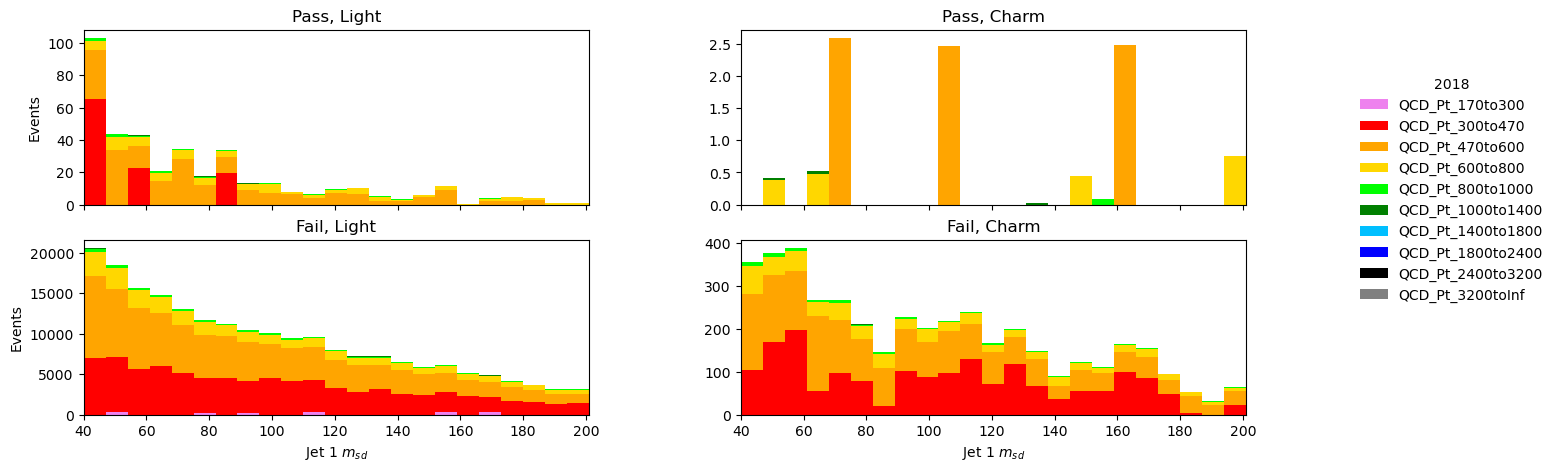

In [17]:
def grid():
    
    fig, ax = plt.subplots(2,2,sharex=True,figsize=(15,5))
    plt.subplots_adjust(wspace=0.3)

    hist.plot1d(pass_light[0],stack=True,ax=ax[0][0],order=datasets,fill_opts={'color':colors})
    ax[0][0].get_legend().remove()
    ax[0][0].set_xlabel('')
    ax[0][0].set_title(histnames[0])
    hist.plot1d(pass_charm[0],stack=True,ax=ax[0][1],order=datasets,fill_opts={'color':colors})
    ax[0][1].get_legend().remove()
    ax[0][1].set_ylabel('')
    ax[0][1].set_xlabel('')
    ax[0][1].set_title(histnames[1])
    hist.plot1d(fail_light[0],stack=True,ax=ax[1][0],order=datasets,fill_opts={'color':colors})
    ax[1][0].get_legend().remove()
#     ax[1][0].set_ylabel('')
#     ax[1][0].set_xlabel('')
    ax[1][0].set_title(histnames[2])
    hist.plot1d(fail_charm[0],stack=True,ax=ax[1][1],order=datasets,fill_opts={'color':colors})
    ax[1][1].get_legend().remove()
    ax[1][1].set_ylabel('')
#     ax[1][1].set_xlabel('')
    ax[1][1].set_title(histnames[3])
#     hist.plot1d(passhists[4],stack=True,ax=ax[1][0],order=datasets,fill_opts={'color':colors})
#     ax[1][0].get_legend().remove()
#     ax[1][0].set_title(histnames[4])
#     hist.plot1d(passhists[5],stack=True,ax=ax[1][1],order=datasets,fill_opts={'color':colors})
#     ax[1][1].get_legend().remove()
#     ax[1][1].set_ylabel('')
#     ax[1][1].set_title(histnames[5])
#     hist.plot1d(passhists[6],stack=True,ax=ax[1][2],order=datasets,fill_opts={'color':colors})
#     ax[1][2].get_legend().remove()
#     ax[1][2].set_ylabel('')
#     ax[1][2].set_title(histnames[6])
#     hist.plot1d(passhists[7],stack=True,ax=ax[1][3],order=datasets,fill_opts={'color':colors})
#     ax[1][3].set_ylabel('')
#     ax[1][3].set_title(histnames[7])
#     ax[1][4].axis('off')
    ax[1][1].legend(bbox_to_anchor=(1.2,2),frameon=False,title=year)
    #plt.suptitle(histnames[i]+' DDB pass')
    plt.show()
    
#     plt.savefig(year+'/qcd-slices.pdf',bbox_to_inches='tight')
#     plt.savefig(year+'/qcd-slices.png',bbox_to_inches='tight')
    
grid()